Installing PyTorch Geometric and dependencies... This may take a minute.
Installation Complete!
Using device: cpu
Using device: cpu
Loading QM9 Dataset...
Initializing Models...
GNN Checkpoint loaded successfully!
DimeNet Checkpoint loaded successfully!

Calculating Final Test MAE...
 Baseline GNN Final Test MAE: 8.6067 eV
 DimeNet++ Final Test MAE:    0.4014 eV

Plotting Training Curves...
Training curves saved to 'loss_curves_comparison.png'


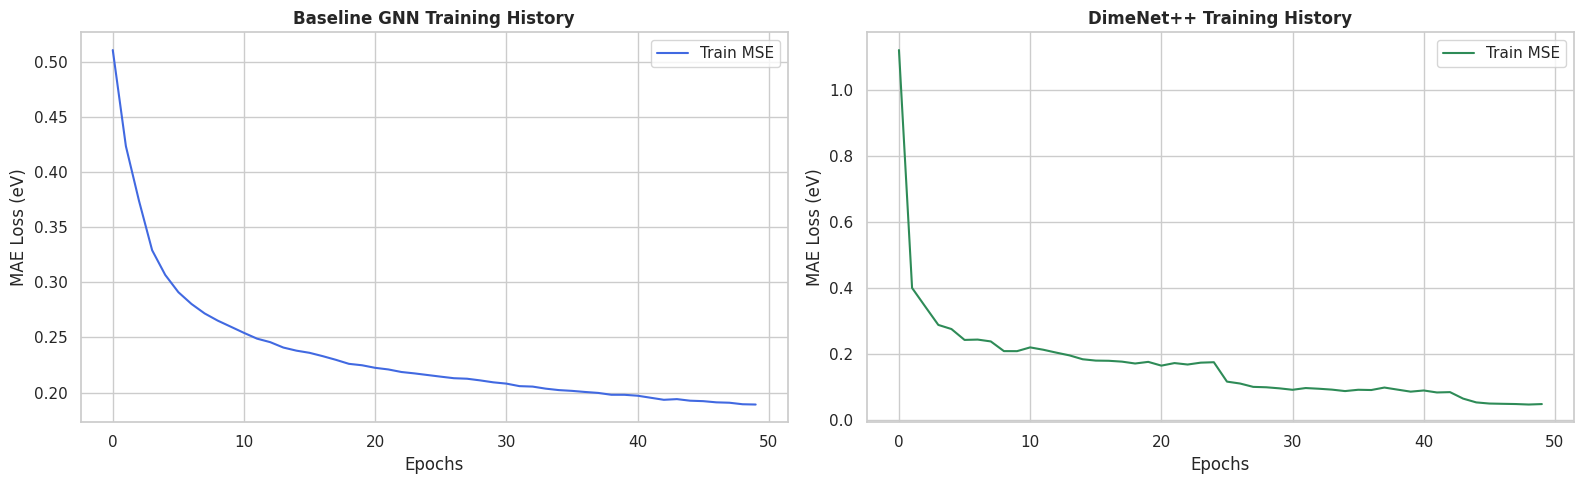


Extracting Embeddings for t-SNE...
[gnn] Hook successfully attached to: out_layer
Extracting gnn embeddings... This may take a moment.
--- Analyzing DimeNet++ ---
[dimenet++] Hook successfully attached to: model.output_blocks.0
Extracting dimenet++ embeddings... This may take a moment.
Computing t-SNE for GNN...
Computing t-SNE for DimeNet++...
Plot saved as 'latent_space_comparison.png'!


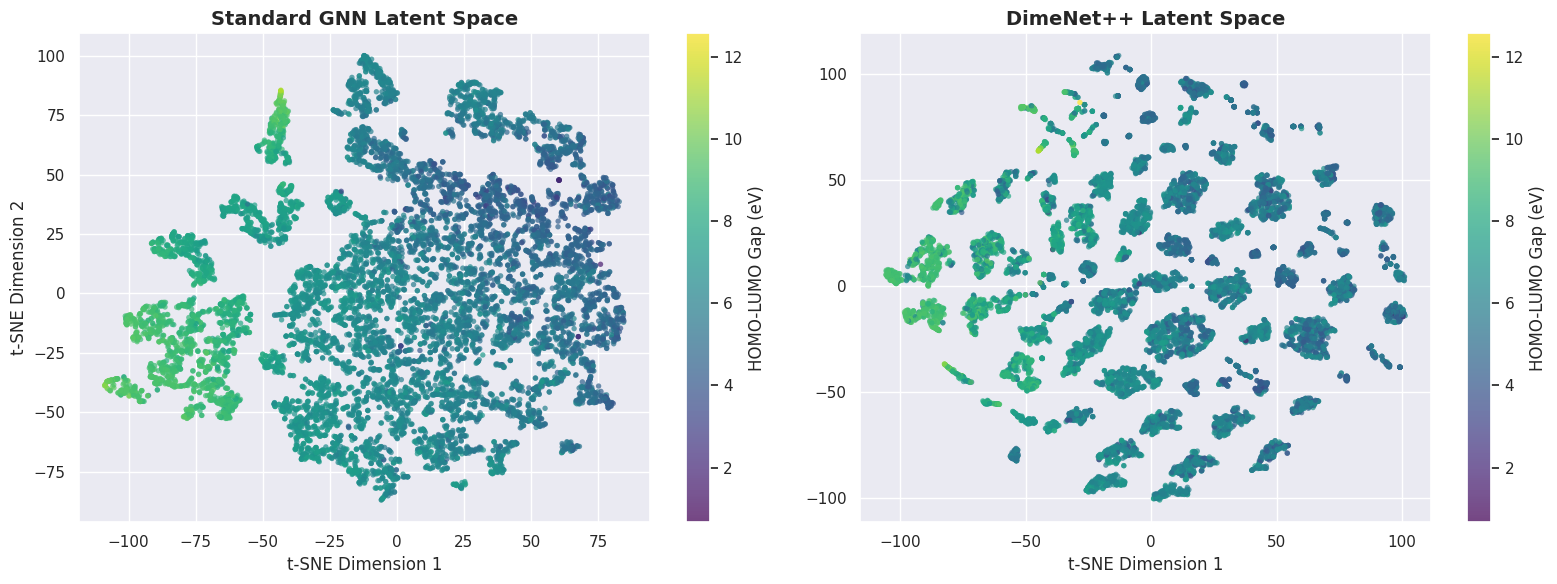

In [4]:
# =====================================================================
# 1. ENVIRONMENT SETUP & INSTALLATION
# =====================================================================
import sys
import subprocess

# ===== Change file paths of Model check points and train loss curves here ======
gnn_train_loss_curve_path = "/content/gnn-train-loss.csv"
dimenet_train_loss_curve_path ="/content/dimenet-train-loss.csv"
GNN_CKPT = "/content/checkpoint_best_gnn.pt"
DIMENET_CKPT = "/content/checkpoint_best_dimenet.pth"
# ==============================================================================


def install_libraries():
    print("Installing PyTorch Geometric and dependencies... This may take a minute.")
    # Installing standard data science and ML libraries
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "seaborn", "scikit-learn", "matplotlib"])

    # Installing PyG and its C++ extensions
    import torch
    TORCH = torch.__version__.split('+')[0]
    CUDA = 'cpu' if not torch.cuda.is_available() else f"cu{torch.version.cuda.replace('.', '')}"

    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "torch-scatter", "torch-sparse", "torch-cluster", "torch-spline-conv",
        "-f", f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html"
    ])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])
    print("Installation Complete!")

# Uncomment the line below if running in a fresh environment (e.g., Google Colab)
install_libraries()

# =====================================================================
# 2. IMPORTS & CONFIGURATION
# =====================================================================
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Sequence

import torch_geometric.nn as gnn
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.models import DimeNet as PyGDimeNet

from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error

dataset = QM9(root='./data/QM9')

dataset = dataset.shuffle() # shuffle dataset for train, test split later

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Train, val, Test split ratio: 80%, 10%, 10%
train_ratio = 0.8
num_train = int(len(dataset) * train_ratio)
num_val = int(len(dataset) * (1-train_ratio)/2)

train_dataset = dataset[:num_train]
val_dataset = dataset[num_train: num_train + num_val]
test_dataset = dataset[num_train + num_val: ]

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

TARGET_INDEX = 4 # HOMO-LUMO gap

target_vals = torch.tensor([data.y[0, TARGET_INDEX].item() for data in train_dataset])

# Calculate mean and standard deviation
TRAIN_MEAN = target_vals.mean().to(device)
TRAIN_STD = target_vals.std().to(device)

# Target specific constants (Replace MEAN and STD with your exact training values)



def denormalize(val):
    """Reverts scaled targets back to physical units (eV)."""
    return (val * TRAIN_STD) + TRAIN_MEAN

# =====================================================================
# 3. MODEL ARCHITECTURES
# =====================================================================
class GNN(torch.nn.Module):
    def __init__(self, in_channels: int, edge_attr_dim: int, gnn_channels: Sequence[int],
                 add_self_loops: bool = True, pool: str = 'global_mean_pool',
                 fc_channels: Sequence[int] = [], activation: str = 'ReLU'):
        super().__init__()
        self.activation = getattr(nn, activation)()
        self.gnn_layers = nn.ModuleList()
        input_channels = in_channels

        for num_layers in gnn_channels:
            self.gnn_layers.append(gnn.conv.GCNConv(input_channels, num_layers, add_self_loops=add_self_loops))
            input_channels = num_layers

        self.edge_encoder = nn.ModuleList([
            nn.Sequential(nn.Linear(in_features=edge_attr_dim, out_features=1), nn.Sigmoid(), nn.Flatten(0))
            for _ in range(len(self.gnn_layers))
        ])

        self.pool = getattr(gnn.pool, pool)
        self.fc_layers = nn.ModuleList()
        current_channels = gnn_channels[-1]
        for fc in fc_channels:
            self.fc_layers.append(nn.Linear(current_channels, fc))
            current_channels = fc

        self.out_layer = nn.Linear(current_channels, 1)

    def forward(self, x, edge_index, edge_attr, batch):
        for i in range(len(self.gnn_layers)):
            edge_weight = self.edge_encoder[i](edge_attr)
            x = self.gnn_layers[i](x, edge_index, edge_weight)
        x = self.pool(x, batch)
        for layer in self.fc_layers:
            x = self.activation(layer(x))
        return self.out_layer(x)

class DimeNet(torch.nn.Module):
    def __init__(self, emb_size, num_blocks, num_bilinear, num_spherical,
                 num_radial, cutoff, envelope_exponent, num_before_skip,
                 num_after_skip, num_dense_output, num_targets, **kwargs):
        super(DimeNet, self).__init__()
        self.model = PyGDimeNet(
            hidden_channels=emb_size, out_channels=num_targets,
            num_blocks=num_blocks, num_bilinear=num_bilinear,
            num_spherical=num_spherical, num_radial=num_radial,
            cutoff=cutoff, envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip, num_after_skip=num_after_skip,
            num_output_layers=num_dense_output
        )

    def forward(self, z, pos, batch):
        return self.model(z, pos, batch)

# =====================================================================
# 4. PLOTTING & EXTRACTION LOGIC
# =====================================================================
def plot_training_history(gnn_log_path, dimenet_log_path):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    if os.path.exists(gnn_log_path):
        gnn_df = pd.read_csv(gnn_log_path)
        axes[0].plot(gnn_df['Step'], gnn_df['chocolate-cloud-5 - train_loss'], label='Train MSE', color='royalblue')
        axes[0].set_title("Baseline GNN Training History", fontweight='bold')
    else:
        axes[0].set_title("GNN Log Not Found", fontweight='bold')

    if os.path.exists(dimenet_log_path):
        dn_df = pd.read_csv(dimenet_log_path)
        axes[1].plot(dn_df['Step'], dn_df['lemon-spaceship-25 - train_loss'], label='Train MSE', color='seagreen')
        axes[1].set_title("DimeNet++ Training History", fontweight='bold')
    else:
        axes[1].set_title("DimeNet++ Log Not Found", fontweight='bold')

    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.set_ylabel("MAE Loss (eV)")
        ax.legend()

    plt.tight_layout()
    plt.savefig("loss_curves_comparison.png", dpi=300)
    print("Training curves saved to 'loss_curves_comparison.png'")
    plt.show()

from torch_geometric.nn import global_mean_pool
import numpy as np
import torch


def extract_embeddings_final(model, loader, device, model_type="gnn", layer_name=""):
    model.eval()
    final_embeddings = []
    targets = []
    temp_storage = []

    def hook_fn(module, input_tuple, output):
        if model_type == "dimenet++":
            x = input_tuple[0].detach().cpu() # High-D edges
            i = input_tuple[2].detach().cpu() # Atom assignments
            temp_storage.append((x, i))
        else:
            out = output[0] if isinstance(output, tuple) else output

            # THE TRICK: If the layer crushes data down to 1 dimension (prediction)
            if out.ndim == 1 or out.shape[-1] == 1:
                # Steal the rich, high-dimensional INPUT instead!
                in_feat = input_tuple[0]
                if isinstance(in_feat, tuple):
                    in_feat = in_feat[0]
                temp_storage.append(in_feat.detach().cpu())
            else:
                # Otherwise, grab the output as usual
                temp_storage.append(out.detach().cpu())

    target_layer = None
    target_name = ""

    if model_type == "dimenet++":
        # THE FIX: Use 'in' to catch 'model.output_blocks.0'
        for name, module in model.named_modules():
            if "output_blocks.0" in name:
                target_layer = module
                target_name = name
                break
    else:
        for name, module in model.named_modules():
            if layer_name and layer_name == name:
                target_layer = module
                target_name = name
                break

    if target_layer is None:
        raise ValueError(f"Could not find the target layer for {model_type}! Check layer_name.")

    print(f"[{model_type}] Hook successfully attached to: {target_name}")
    hook_handle = target_layer.register_forward_hook(hook_fn)

    print(f"Extracting {model_type} embeddings... This may take a moment.")
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            if model_type == "dimenet++":
                _ = model(data.z, data.pos, data.batch)
                x, i = temp_storage.pop()
                edge_batch = data.batch.cpu()[i]
                graph_embs = global_mean_pool(x, edge_batch)
                final_embeddings.append(graph_embs.numpy())

            else:
                _ = model(data.x, data.edge_index, data.edge_attr, data.batch)
                graph_embs = temp_storage.pop()
                final_embeddings.append(graph_embs.numpy())

            targets.append(data.y[:, 4].cpu().numpy())

    hook_handle.remove()
    return np.concatenate(final_embeddings, axis=0), np.concatenate(targets, axis=0)

def plot_latent_space_comparison(gnn_embeddings, gnn_targets, dimenet_embeddings, dimenet_targets):

    print("Computing t-SNE for GNN...")
    tsne_gnn = TSNE(n_components=2, perplexity=30, random_state=42)
    gnn_2d = tsne_gnn.fit_transform(gnn_embeddings)

    print("Computing t-SNE for DimeNet++...")
    tsne_dimenet = TSNE(n_components=2, perplexity=30, random_state=42)
    dimenet_2d = tsne_dimenet.fit_transform(dimenet_embeddings)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot GNN
    sc1 = axes[0].scatter(
        gnn_2d[:, 0], gnn_2d[:, 1],
        c=gnn_targets, cmap='viridis',
        s=15, alpha=0.7, edgecolors='none'
    )
    axes[0].set_title("Standard GNN Latent Space", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    fig.colorbar(sc1, ax=axes[0], label="HOMO-LUMO Gap (eV)")

    # Plot DimeNet++
    sc2 = axes[1].scatter(
        dimenet_2d[:, 0], dimenet_2d[:, 1],
        c=dimenet_targets, cmap='viridis',
        s=15, alpha=0.7, edgecolors='none'
    )
    axes[1].set_title("DimeNet++ Latent Space", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("t-SNE Dimension 1")

    fig.colorbar(sc2, ax=axes[1], label="HOMO-LUMO Gap (eV)")

    plt.tight_layout()
    plt.savefig("latent_space_comparison.png", dpi=300)
    print("Plot saved as 'latent_space_comparison.png'!")
    plt.show()

# =====================================================================
# 5. MAIN EXECUTION PIPELINE
# =====================================================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load Data
    print("Loading QM9 Dataset...")
    dataset = QM9(root='data/QM9')

    # Train, val, Test split ratio: 80%, 10%, 10%
    train_ratio = 0.8
    num_train = int(len(dataset) * train_ratio)
    num_val = int(len(dataset) * (1-train_ratio)/2)

    train_dataset = dataset[:num_train]
    val_dataset = dataset[num_train: num_train + num_val]
    test_dataset = dataset[num_train + num_val: ]

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize Models
    print("Initializing Models...")
    model_gnn = GNN(
        in_channels=dataset.num_node_features,
        edge_attr_dim=dataset.num_edge_features,
        gnn_channels=[128, 128],
        add_self_loops=True,
        pool="global_max_pool",
        fc_channels=[128, 64, 32],
        activation="SiLU"
    ).to(device)

    model_dimenet = DimeNet(
            emb_size= 128,
            num_blocks= 2,
            num_bilinear=8,
            num_spherical=7,
            num_radial=6,
            cutoff= 5.0,
            envelope_exponent=5,
            num_before_skip=1,
            num_after_skip=2,
            num_dense_output=3,
            num_targets=1
        ).to(device)



    checkpoint_dimenet = torch.load("/content/checkpoints_best_dimenet_run_dsogz7xo.pth", map_location=device, weights_only=False)
    checkpoint_gnn = torch.load("/content/best_model_Experiment 4 (1).pt", map_location=device, weights_only=False)

    model_gnn.load_state_dict(checkpoint_gnn["model_state_dict"])
    print("GNN Checkpoint loaded successfully!")

    model_dimenet.load_state_dict(checkpoint_dimenet)
    print("DimeNet Checkpoint loaded successfully!")

    model_gnn.eval()
    model_dimenet.eval()

    y_true, p_gnn, p_dn = [], [], []

    print("\nCalculating Final Test MAE...")
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            p_gnn.append(denormalize(model_gnn(data.x, data.edge_index, data.edge_attr, data.batch)).cpu().numpy())
            p_dn.append(denormalize(model_dimenet(data.z, data.pos, data.batch)).cpu().numpy())
            y_true.append(denormalize(data.y[:, TARGET_INDEX]).cpu().numpy())

    mae_gnn = mean_absolute_error(np.concatenate(y_true), np.concatenate(p_gnn))
    mae_dn = mean_absolute_error(np.concatenate(y_true), np.concatenate(p_dn))

    print("=========================================")
    print(f" Baseline GNN Final Test MAE: {mae_gnn:.4f} eV")
    print(f" DimeNet++ Final Test MAE:    {mae_dn:.4f} eV")
    print("=========================================\n")

    # 2. Plot Training Curves (Update paths to your actual CSVs)
    print("Plotting Training Curves...")
    plot_training_history(gnn_train_loss_curve_path, dimenet_train_loss_curve_path)

    # 3. Plot Latent Space
    print("\nExtracting Embeddings for t-SNE...")
    gnn_layer_name = list(model_gnn.named_children())[-1][0]

    gnn_emb, gnn_y = extract_embeddings_final(
        model_gnn, test_loader, device,
        model_type="gnn",
        layer_name=gnn_layer_name
    )

    # For PyG DimeNetPlusPlus, "output_blocks" will naturally find the output blocks
    # and our script will grab the atom embeddings right before the final block processes them.
    dimenet_emb, dimenet_y = extract_embeddings_final(
    model_dimenet, test_loader, device,
    model_type="dimenet++"
)

    plot_latent_space_comparison(gnn_emb, gnn_y, dimenet_emb, dimenet_y)